In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
url=URL.create(
    "mysql+pymysql",
    username = "root",
    password="Akash@735030",
    host="localhost",
    port=3306,
    database="Inventory"
)
engine = create_engine(url)
print("Connection Successfully")

Connection Successfully


In [3]:
df = pd.read_sql("Select * from vendor_sales_summary",engine)
df.head()

,VendorNumber,VendorName,Brand,PurchasePrice,Description,Actual_Price,volume,TotalPurchasesQuantity,TotalPurchasesDollers,TotalSalesDollers,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,Freight_Summary,GrossProfit,ProfitMargin,StockTurnover
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,23.86,Ch Lilian 09 Ladouys St Este,36.99,750.0,8,190.88,73.98,36.99,2,0.22,27.08,-116.90,-158.02,0.25
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,17.00,Flavor Essence Variety 5 Pak,24.99,162.5,320,5440.00,0.00,0.00,0,0.00,27.08,-5440.00,NaN,0.00
2,54,AAPER ALCOHOL & CHEMICAL CO,990,105.07,Ethyl Alcohol 200 Proof,134.49,3750.0,1,105.07,0.00,0.00,0,0.00,0.48,-105.07,NaN,0.00
3,60,ADAMBA IMPORTS INTL INC,771,11.44,Bak's Krupnik Honey Liqueur,14.99,750.0,39,446.16,0.00,0.00,0,0.00,367.52,-446.16,NaN,0.00
4,60,ADAMBA IMPORTS INTL INC,3401,11.10,Vesica Vodka,14.99,1750.0,6,66.60,0.00,0.00,0,0.00,367.52,-66.60,NaN,0.00


In [4]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'PurchasePrice', 'Description',
       'Actual_Price', 'volume', 'TotalPurchasesQuantity',
       'TotalPurchasesDollers', 'TotalSalesDollers', 'TotalSalesPrice',
       'TotalSalesQuantity', 'TotalExciseTax', 'Freight_Summary',
       'GrossProfit', 'ProfitMargin', 'StockTurnover'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   VendorNumber            10692 non-null  int64  
 1   VendorName              10692 non-null  object 
 2   Brand                   10692 non-null  int64  
 3   PurchasePrice           10692 non-null  float64
 4   Description             10692 non-null  object 
 5   Actual_Price            10692 non-null  float64
 6   volume                  10692 non-null  float64
 7   TotalPurchasesQuantity  10692 non-null  int64  
 8   TotalPurchasesDollers   10692 non-null  float64
 9   TotalSalesDollers       10692 non-null  float64
 10  TotalSalesPrice         10692 non-null  float64
 11  TotalSalesQuantity      10692 non-null  int64  
 12  TotalExciseTax          10692 non-null  float64
 13  Freight_Summary         10692 non-null  float64
 14  GrossProfit             10692 non-null

In [6]:
df.isnull().sum()

VendorNumber                 0
VendorName                   0
Brand                        0
PurchasePrice                0
Description                  0
Actual_Price                 0
volume                       0
TotalPurchasesQuantity       0
TotalPurchasesDollers        0
TotalSalesDollers            0
TotalSalesPrice              0
TotalSalesQuantity           0
TotalExciseTax               0
Freight_Summary              0
GrossProfit                  0
ProfitMargin              3550
StockTurnover                0
dtype: int64

In [7]:
df['ProfitMargin'] = df['ProfitMargin'].fillna(0)

In [8]:
df.isnull().sum()

VendorNumber              0
VendorName                0
Brand                     0
PurchasePrice             0
Description               0
Actual_Price              0
volume                    0
TotalPurchasesQuantity    0
TotalPurchasesDollers     0
TotalSalesDollers         0
TotalSalesPrice           0
TotalSalesQuantity        0
TotalExciseTax            0
Freight_Summary           0
GrossProfit               0
ProfitMargin              0
StockTurnover             0
dtype: int64

#### Exploratory Data Analysis
 
###### Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
 
###### In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
Brand,10692.0,18039.228769,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
PurchasePrice,10692.0,24.385303,109.269375,0.36,6.8400,10.455,19.4825,5681.81
Actual_Price,10692.0,35.643671,148.246016,0.49,10.9900,15.990,28.9900,7499.99
volume,10692.0,847.360550,664.309212,50.00,750.0000,750.000,750.0000,20000.00
TotalPurchasesQuantity,10692.0,3140.886831,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
TotalPurchasesDollers,10692.0,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
TotalSalesDollers,10692.0,3088.393308,12177.745632,0.00,0.0000,251.740,2088.9000,444810.74
TotalSalesPrice,10692.0,1507.690857,3900.873963,0.00,0.0000,125.975,1220.0125,64889.97
TotalSalesQuantity,10692.0,228.791900,870.839573,0.00,0.0000,12.000,129.0000,28544.00


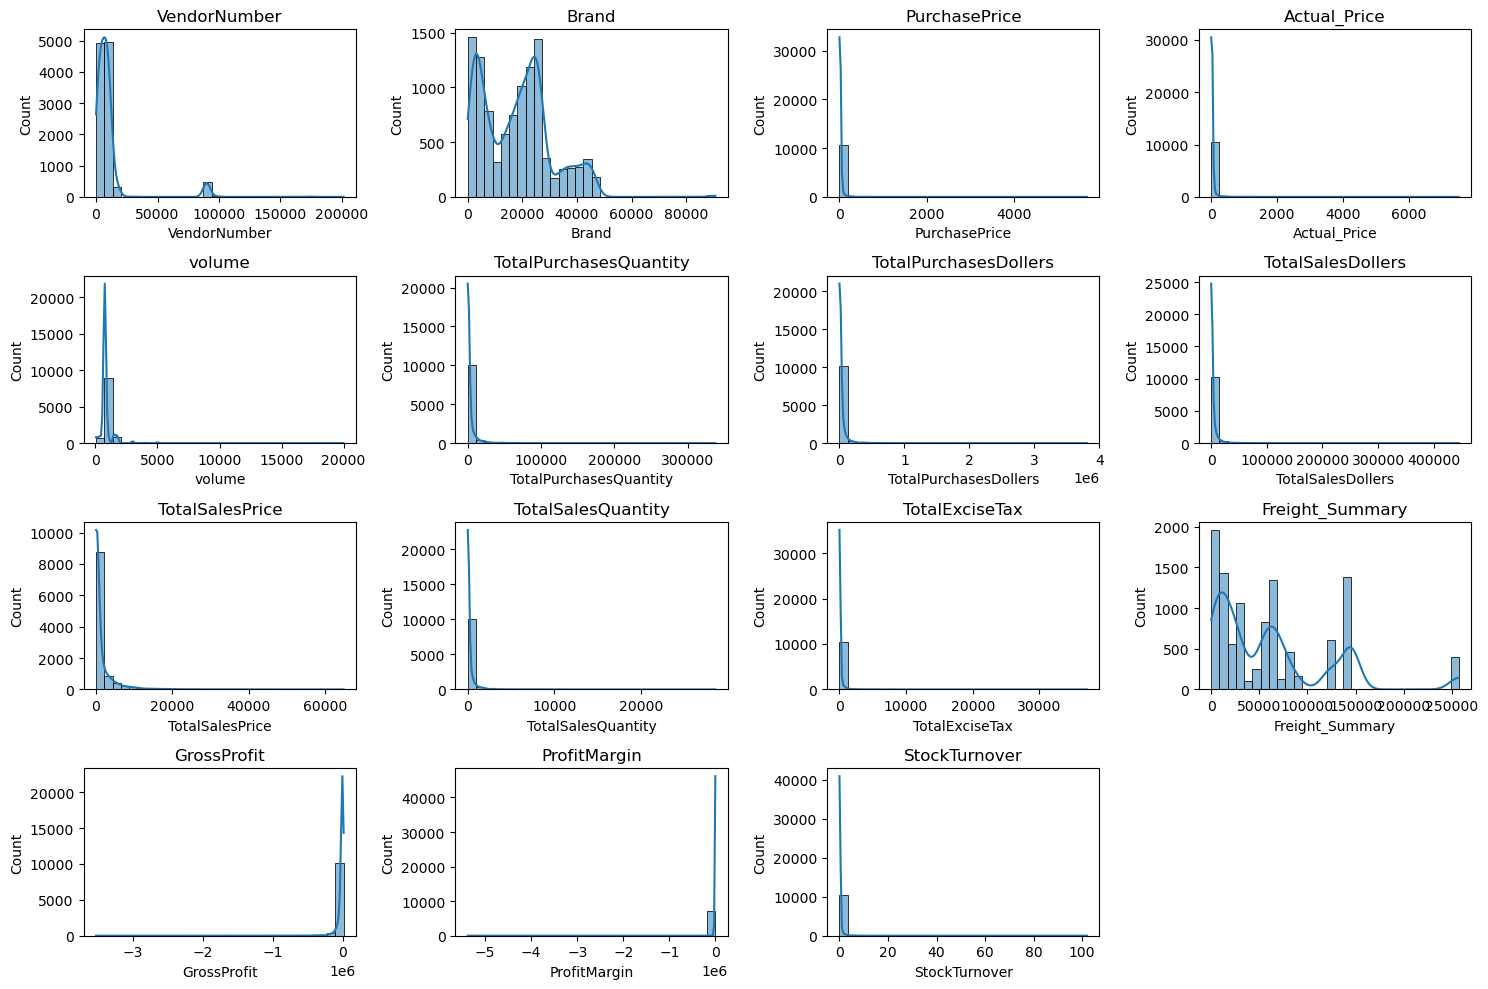

In [8]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns 

plt.figure(figsize=(15, 10))
for i, col in enumerate (numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed
    sns.histplot(df [col], kde=True, bins=30)
    plt.title(col) 
plt.tight_layout()
plt.show()

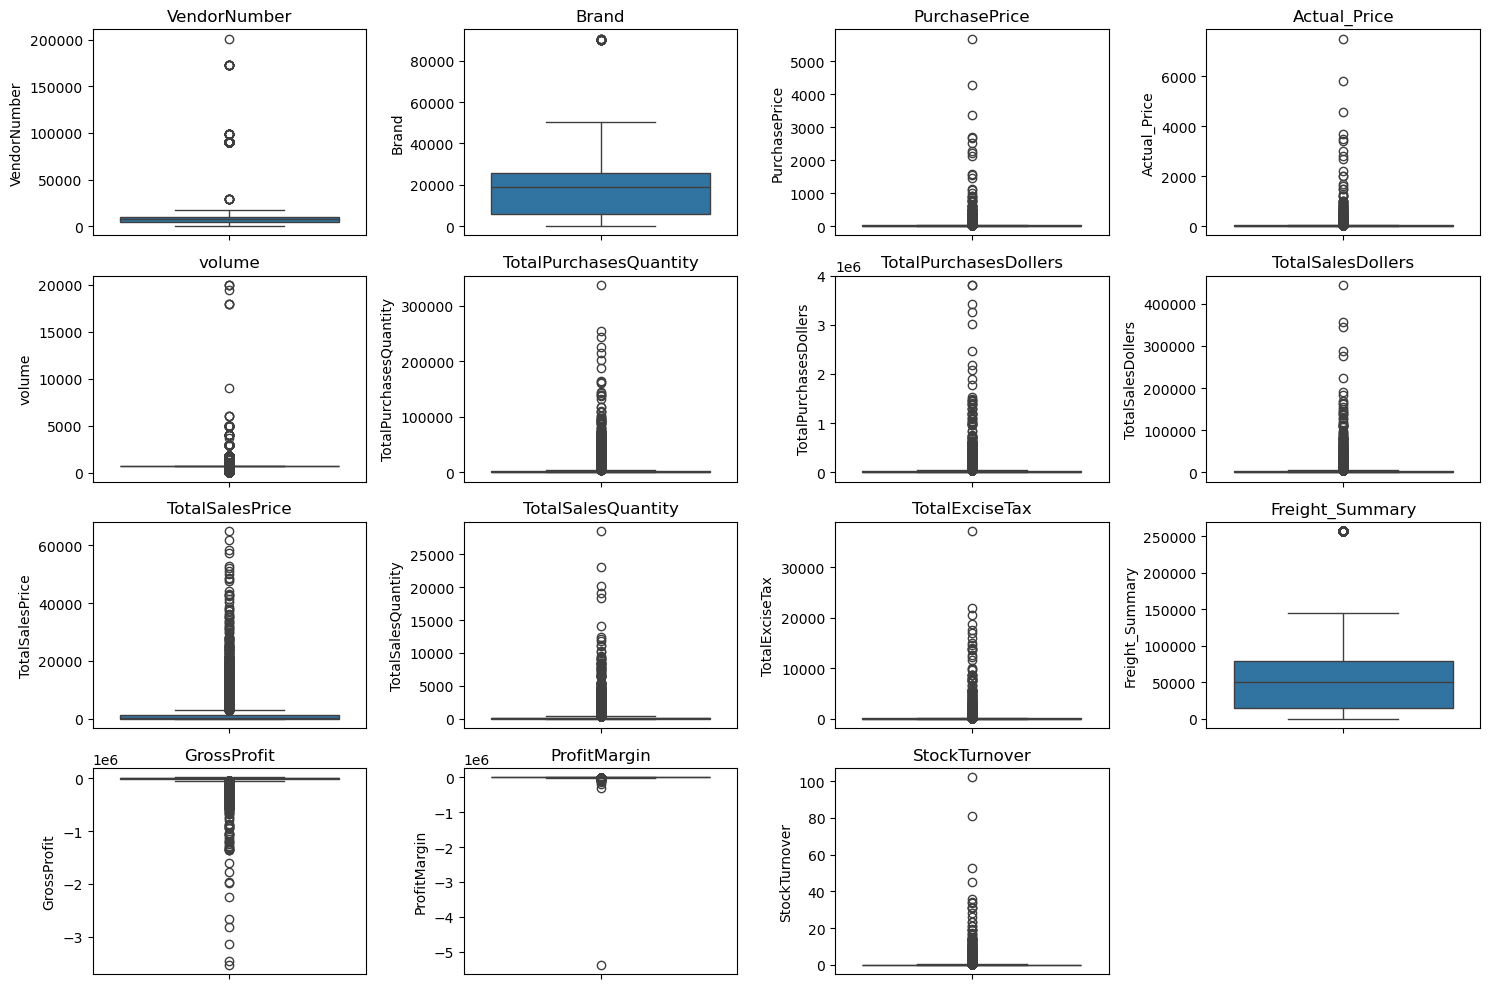

In [9]:
# Outlier Detection with Boxplot

plt.figure(figsize=(15, 10))
for i, col in enumerate (numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col) 
plt.tight_layout()
plt.show()

### Summary Statistics Insights:
 
#### Negative & Zero Values:
 
##### 1) Gross Profit: Minimum value is -3528878.25, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
 
##### 2) Profit Margin: Has a minimum of -5379399.71, which suggests cases where revenue is zero or even lower than costs.
 
##### 3) Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.
 
#### Outliers Indicated by High Standard Deviations:
 
##### 1)Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
 
##### 2) Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
 
##### 3) Stock Turnover: Ranges from 0 to 102.00, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [10]:
## Lets filter the data by removing in consistencies
df = pd.read_sql_query('''select * from vendor_sales_summary
where GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0''',engine)

In [11]:
df

,VendorNumber,VendorName,Brand,PurchasePrice,Description,Actual_Price,volume,TotalPurchasesQuantity,TotalPurchasesDollers,TotalSalesDollers,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,Freight_Summary,GrossProfit,ProfitMargin,StockTurnover
0,388,ATLANTIC IMPORTING COMPANY,7241,20.68,Glendalough Poitin Shry Cask,34.99,750.0,31,641.08,749.75,719.76,25,2.75,211.74,108.67,14.49,0.81
1,480,BACARDI USA INC,540,0.72,Bacardi Pineapple Fusion,0.99,50.0,352,253.44,1069.20,453.42,1080,55.67,89286.27,815.76,76.30,3.07
2,480,BACARDI USA INC,973,11.90,Bacardi 1873 Solera Rum,19.99,750.0,21,249.90,329.78,239.84,22,17.34,89286.27,79.88,24.22,1.05
3,480,BACARDI USA INC,1020,18.11,B & B Dom VAP,28.99,750.0,2,36.22,1174.53,824.67,47,37.06,89286.27,1138.31,96.92,23.50
4,480,BACARDI USA INC,1414,14.28,Bacardi 8 Gift Set,23.99,750.0,5,71.40,669.73,244.90,27,21.27,89286.27,598.33,89.34,5.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,90047,CRUSH WINES,18394,10.96,Ravines Gewurztraminer,16.99,750.0,1,10.96,16.99,16.99,1,0.11,1457.73,6.03,35.49,1.00
677,90047,CRUSH WINES,22168,7.43,Tangent Pnt Gris,10.99,750.0,79,586.97,681.38,274.75,62,6.92,1457.73,94.41,13.86,0.78
678,90047,CRUSH WINES,22831,9.08,Grady Family Vyds Znfdl,14.99,750.0,24,217.92,335.76,27.98,24,2.70,1457.73,117.84,35.10,1.00
679,90047,CRUSH WINES,23218,6.70,Tangent Chard,9.99,750.0,663,4442.10,6993.00,3086.91,700,78.00,1457.73,2550.90,36.48,1.06


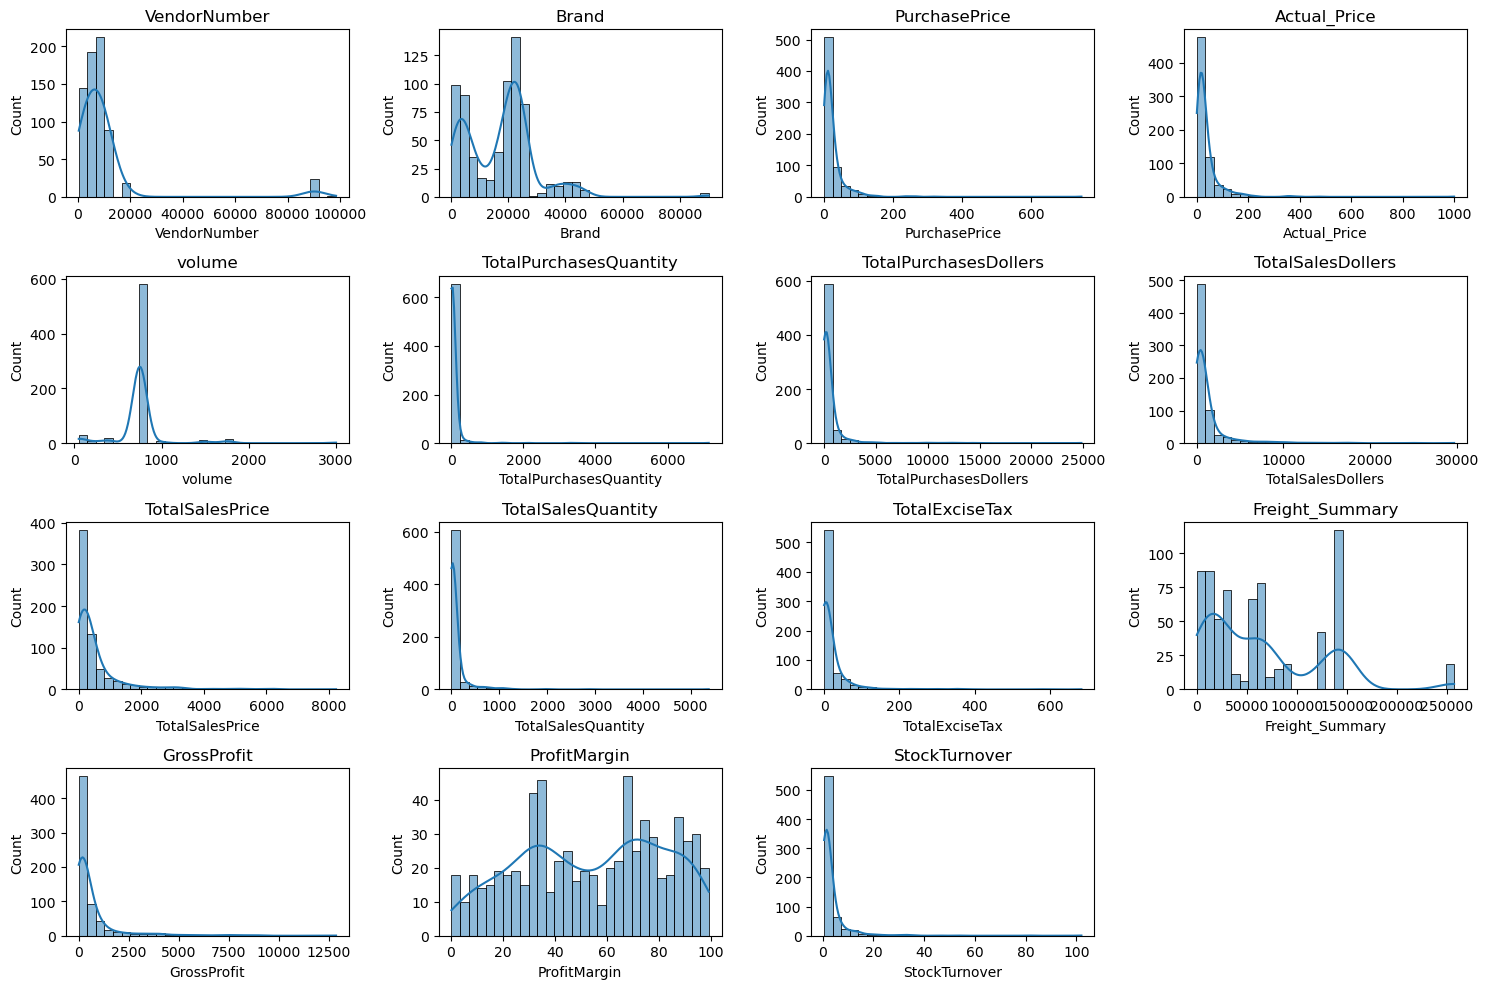

In [12]:
plt.figure(figsize=(15, 10))
for i, col in enumerate (numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed
    sns.histplot(df [col], kde=True, bins=30)
    plt.title(col) 
plt.tight_layout()
plt.show()

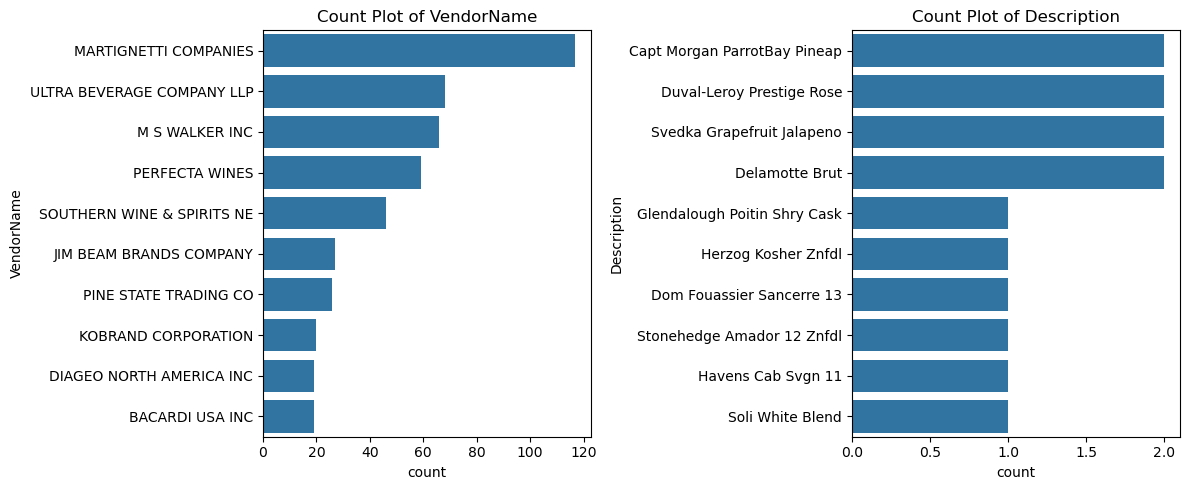

In [13]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]
 
plt.figure(figsize=(12, 5))
for i, col in enumerate (categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}") 
plt.tight_layout()
plt.show()

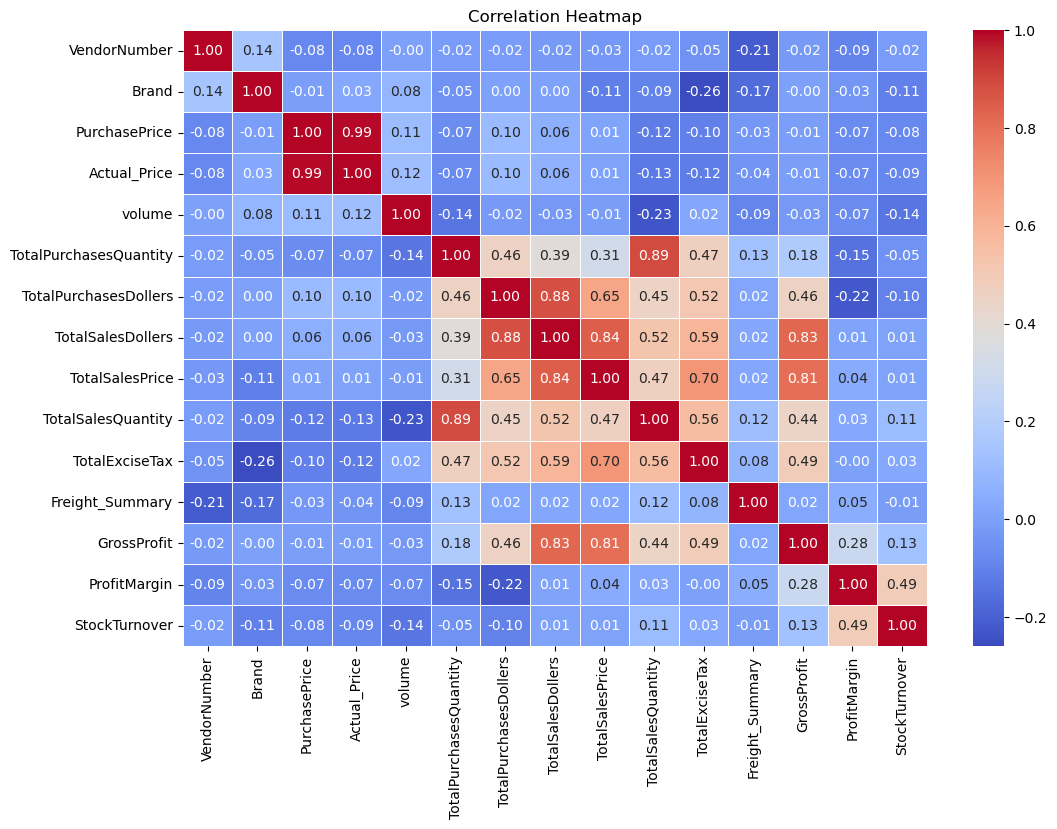

In [14]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights
 
##### 1) PurchasePrice has weak correlations with TotalSales Dollars and Gross Profit, suggesting that price variations do not significantly impact sales revenue or profit.
 
##### 2) Strong correlation between total purchase quantity and total sales quantity, confirming efficient inventory turnover.
 
##### 3) Negative correlation between profit margin & total sales price suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
 
##### 4) Stock Turnover has weak negative correlations with both GrossProfit and ProfitMargin, indicating that faster turnover does not necessarily result in higher profitability

## DATA ANALYSIS

## Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [15]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollers':'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [16]:
low_sales_threshold = brand_performance['TotalSalesDollers'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [17]:
low_sales_threshold

np.float64(119.832)

In [18]:
high_margin_threshold

np.float64(87.418)

In [19]:
# filter brand with low sales but high profit margin
target_brand = brand_performance[
    (brand_performance['TotalSalesDollers'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print('Brands with low sales but High Profit Margin :')
display(target_brand.sort_values('TotalSalesDollers'))

Brands with low sales but High Profit Margin :


,Description,TotalSalesDollers,ProfitMargin
616,The Club Strawbry Margarita,11.94,87.69
229,Crown Royal Apple,23.88,88.11
635,Tracia Syrah,44.94,88.50
46,Bacardi Oakheart Spiced Trav,59.94,87.55
256,Dr McGillicuddy's Apple Pie,62.72,96.27
579,St Elder Elderflower Liqueur,66.33,91.44
31,Aresti Pnt Nr Curico Vly,74.85,95.62
239,DeKuyper Buttershots Trav,76.93,90.72
626,Three Olives Grape Vodka,80.19,99.11
580,St Germain Liqueur,89.94,87.66


In [20]:
brand_performance1 = brand_performance[brand_performance['TotalSalesDollers']<1000] # for visualization

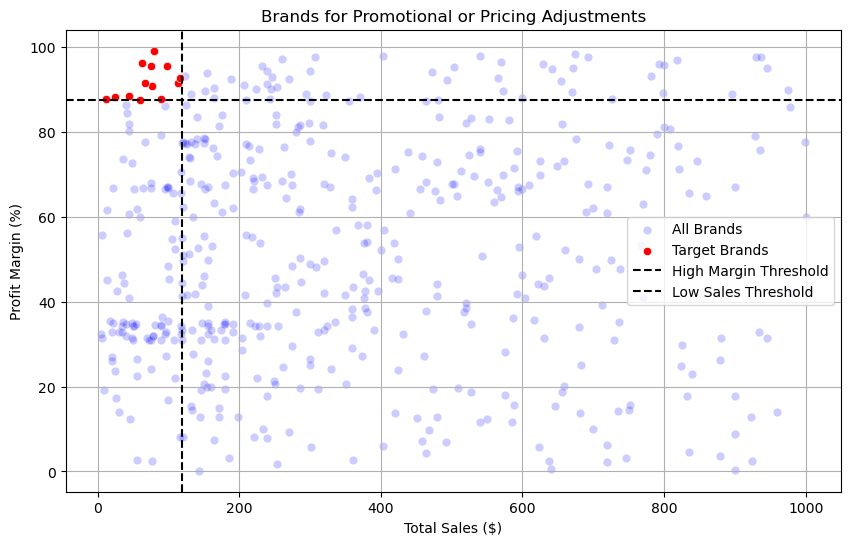

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance1, x='TotalSalesDollers', y='ProfitMargin', color="blue", label="All Brands", alpha= 0.2)
sns.scatterplot(data=target_brand, x='TotalSalesDollers', y='ProfitMargin', color="red", label="Target Brands")
 
plt.axhline(high_margin_threshold, linestyle = '--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle = '--', color='black', label="Low Sales Threshold")
 
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

## Which Vendor and brand demonstrate the highest sales performance ?

In [22]:
def format_dollers(value):
    if value>= 1_00_000:
        return f"{value / 1_00_000}M"
    elif value>= 1_000:
        return f"{value / 1_000}K"
    else:
        return str(value)

In [23]:
# Top vendor & brand by sales performance
top_vendors = df.groupby('VendorName')['TotalSalesDollers'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollers'].sum().nlargest(10)

In [24]:
top_vendors

VendorName
ULTRA BEVERAGE COMPANY LLP    132226.54
MARTIGNETTI COMPANIES         125884.74
M S WALKER INC                100939.71
PERFECTA WINES                 62686.86
BACARDI USA INC                49095.12
SOUTHERN WINE & SPIRITS NE     48248.55
STATE WINE & SPIRITS           30773.64
JIM BEAM BRANDS COMPANY        28761.34
DIAGEO NORTH AMERICA INC       22506.09
BROWN-FORMAN CORP              20504.19
Name: TotalSalesDollers, dtype: float64

In [25]:
top_brands

Description
Ch La Rousseliere St Estephe    29698.02
Madison's Ranch Cab Svgn        24797.91
Bacardi Twin Pack 2/750mls      17331.33
Paul Dolan 12 Cab Svgn          17253.49
DiSaronna Amaretto Sour VAP     15596.83
Pizzolato Pnt Grigio            14252.61
Robert Hall Cab Svgn            12912.77
Latour 12 Cuvee Bourg Rouge     12273.86
Bacardi Superior Rum            11411.40
Saddleback Clrs 09 Cab Svgn     10447.25
Name: TotalSalesDollers, dtype: float64

In [26]:
top_brands.apply(lambda x: format_dollers(round(x, 2)))

Description
Ch La Rousseliere St Estephe              29.69802K
Madison's Ranch Cab Svgn        24.797909999999998K
Bacardi Twin Pack 2/750mls                17.33133K
Paul Dolan 12 Cab Svgn          17.253490000000003K
DiSaronna Amaretto Sour VAP               15.59683K
Pizzolato Pnt Grigio                      14.25261K
Robert Hall Cab Svgn                      12.91277K
Latour 12 Cuvee Bourg Rouge               12.27386K
Bacardi Superior Rum                       11.4114K
Saddleback Clrs 09 Cab Svgn               10.44725K
Name: TotalSalesDollers, dtype: object

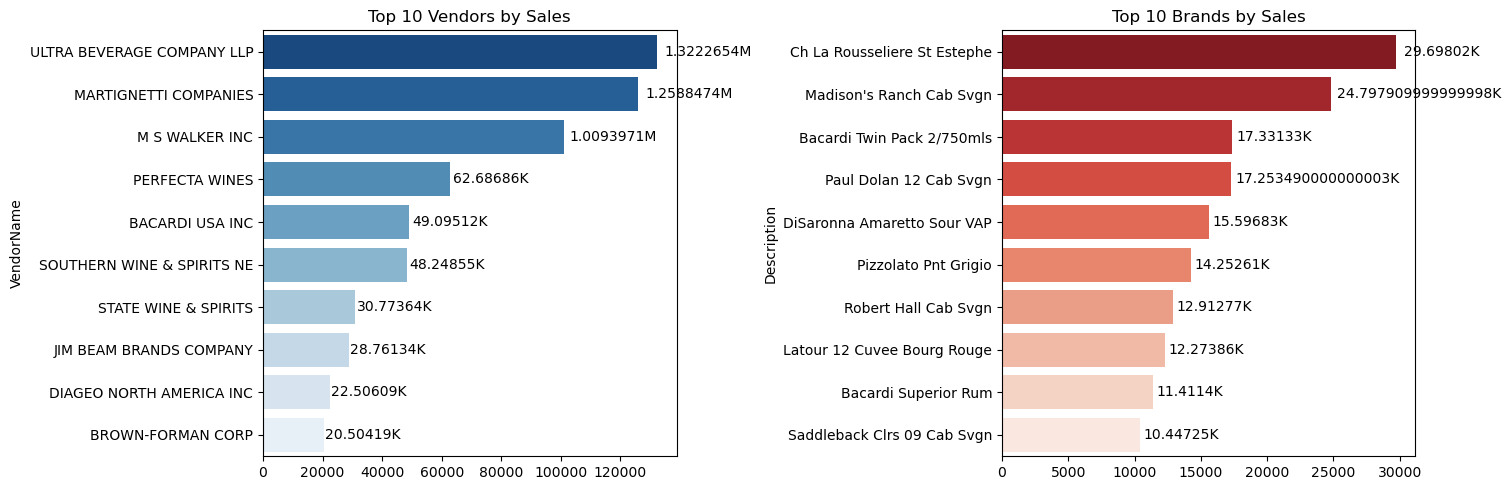

In [27]:
plt.figure(figsize=(15, 5))
 
#Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r") 
plt.title("Top 10 Vendors by Sales")
 
for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2,
             format_dollers(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')
 
#Plot for Top Brands
plt.subplot(1, 2, 2) 
ax2 = sns.barplot(y=top_brands.index.astype(str),x=top_brands.values, palette="Reds_r") 
plt.title("Top 10 Brands by Sales")
 
for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_dollers(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

## Which vendor Contribute the most to total puchase dollers ?

In [28]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchasesDollers':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollers':'sum'
}).reset_index()

In [29]:
vendor_performance['PurchaseContribution%'] = (vendor_performance['TotalPurchasesDollers'] / vendor_performance['TotalPurchasesDollers'].sum())*100

In [30]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [31]:
top_vendors = vendor_performance.head(10)
top_vendors['TotalPurchasesDollers'] = top_vendors['TotalPurchasesDollers'].apply(format_dollers)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollers)
top_vendors['TotalSalesDollers'] = top_vendors['TotalSalesDollers'].apply(format_dollers)
top_vendors

,VendorName,TotalPurchasesDollers,GrossProfit,TotalSalesDollers,PurchaseContribution%
56,ULTRA BEVERAGE COMPANY LLP,51.492839999999994K,80.7337K,1.3222654M,13.54
30,MARTIGNETTI COMPANIES,49.356269999999995K,76.52847K,1.2588474M,12.97
28,M S WALKER INC,48.474199999999996K,52.46551K,1.0093971000000002M,12.74
37,PERFECTA WINES,40.42866K,22.258200000000002K,62.68686K,10.63
2,BACARDI USA INC,28.82943K,20.26569K,49.09512K,7.58
47,SOUTHERN WINE & SPIRITS NE,20.94479K,27.303759999999997K,48.24855K,5.51
24,JIM BEAM BRANDS COMPANY,14.29329K,14.46805K,28.76134K,3.76
13,DIAGEO NORTH AMERICA INC,14.02036K,8.48573K,22.50609K,3.69
48,STATE WINE & SPIRITS,11.69896K,19.07468K,30.77364K,3.08
38,PERNOD RICARD USA,10.7596K,9.57317K,20.33277K,2.83


In [32]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchasesDollers,GrossProfit,TotalSalesDollers,PurchaseContribution%,Cumulative_Contribution%
56,ULTRA BEVERAGE COMPANY LLP,51.492839999999994K,80.7337K,1.3222654M,13.54,13.54
30,MARTIGNETTI COMPANIES,49.356269999999995K,76.52847K,1.2588474M,12.97,26.51
28,M S WALKER INC,48.474199999999996K,52.46551K,1.0093971000000002M,12.74,39.25
37,PERFECTA WINES,40.42866K,22.258200000000002K,62.68686K,10.63,49.88
2,BACARDI USA INC,28.82943K,20.26569K,49.09512K,7.58,57.46
47,SOUTHERN WINE & SPIRITS NE,20.94479K,27.303759999999997K,48.24855K,5.51,62.97
24,JIM BEAM BRANDS COMPANY,14.29329K,14.46805K,28.76134K,3.76,66.73
13,DIAGEO NORTH AMERICA INC,14.02036K,8.48573K,22.50609K,3.69,70.42
48,STATE WINE & SPIRITS,11.69896K,19.07468K,30.77364K,3.08,73.50
38,PERNOD RICARD USA,10.7596K,9.57317K,20.33277K,2.83,76.33


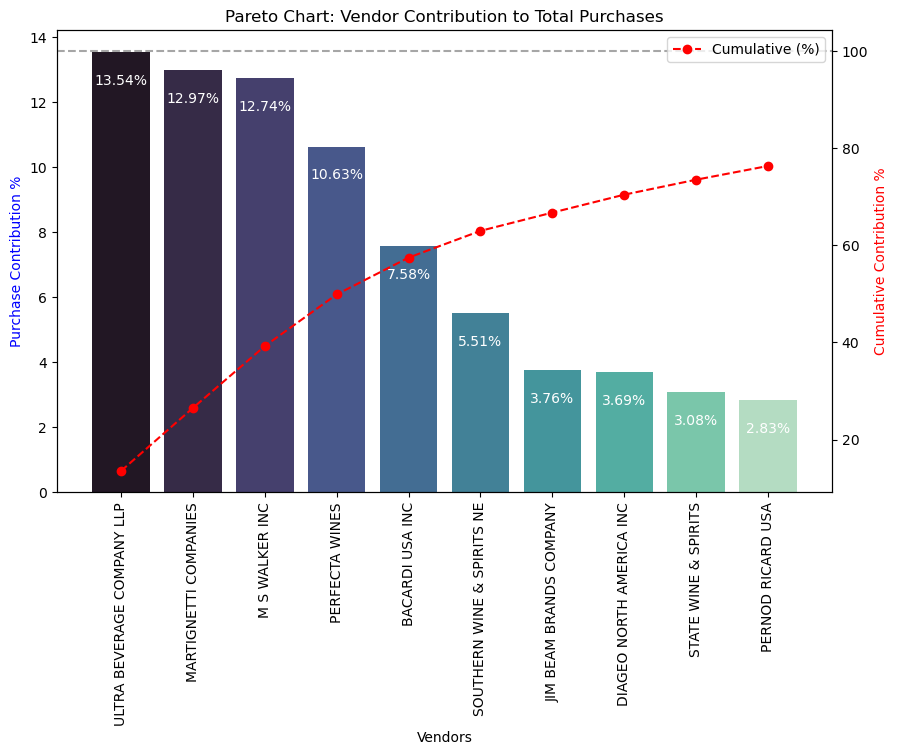

In [33]:
fig, ax1 = plt.subplots(figsize=(10, 6))
 
#Bar plot for Purchase Contribution
sns.barplot(x=top_vendors['VendorName'],y=top_vendors ['PurchaseContribution%'], palette="mako", ax=ax1)
 
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')
 
#Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors ['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative (%)')
 
ax1.set_xticklabels(top_vendors ['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2. legend (loc='upper right')
 
plt.show()

## How much of total procurement is dependent on the top vendors ?

In [34]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 76.33 %


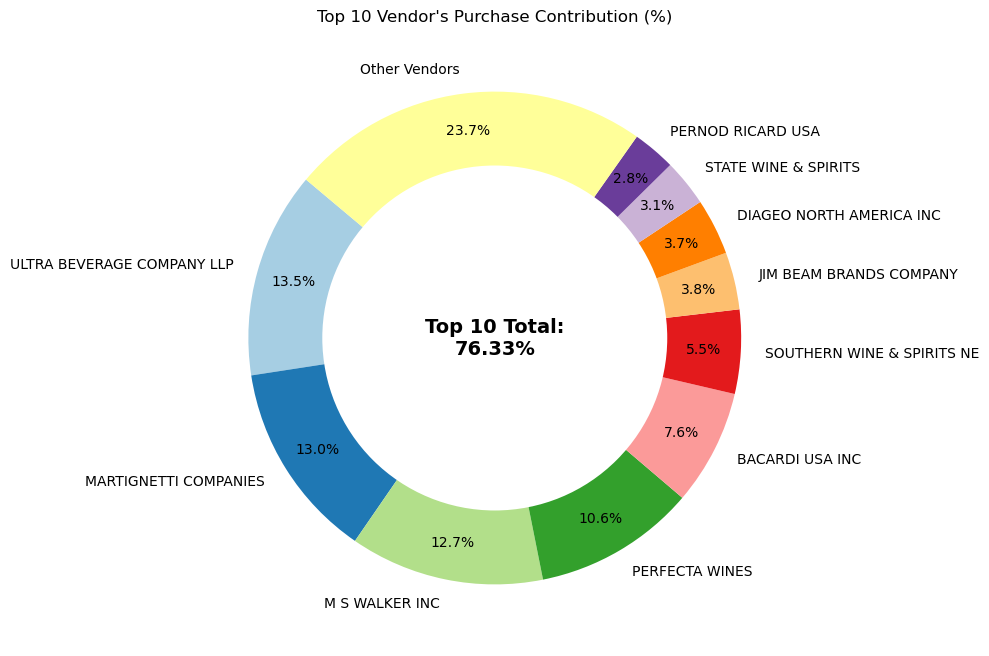

In [35]:
vendors = list(top_vendors ['VendorName'].values)
purchase_contributions = list(top_vendors ['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution
 
# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)
 
#Donut Chart
fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contributions,labels = vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors = plt.cm.Paired.colors)
 
#Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
 
#Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')
 
plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

Does purchasing bulk reduce the unit price, and what is the optimal purchase volume for cost savings ?

In [36]:
df['UnitPurchasePrice'] = df['TotalPurchasesDollers'] / df['TotalPurchasesQuantity']

In [37]:
df['OrderSize'] = pd.qcut(df['TotalPurchasesQuantity'],q=3,labels=["Small","Medium","Large"])

In [38]:
df[['OrderSize','TotalPurchasesQuantity']].head()

,OrderSize,TotalPurchasesQuantity
0,Large,31
1,Large,352
2,Medium,21
3,Small,2
4,Small,5


In [39]:
df.groupby('OrderSize')['UnitPurchasePrice'].mean()

OrderSize
Small     36.700159
Medium    22.570569
Large     11.932248
Name: UnitPurchasePrice, dtype: float64

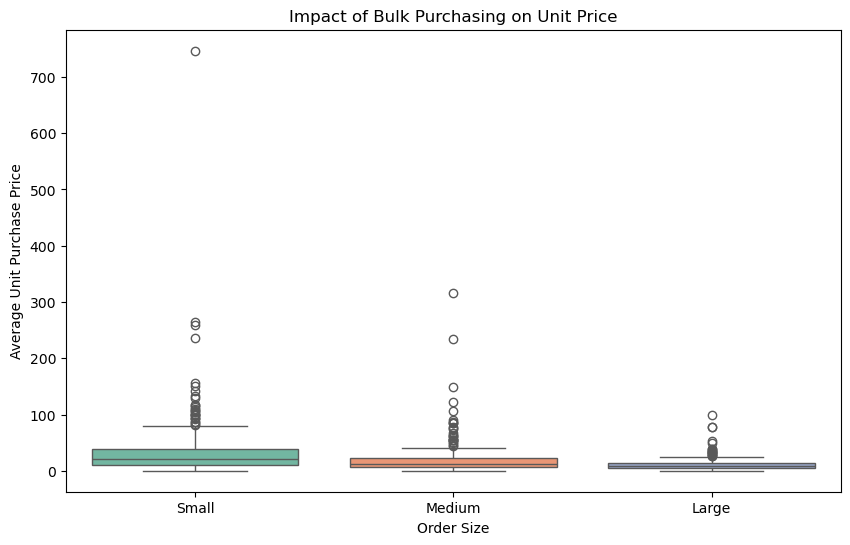

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

##### 1) Vendors buying in bulk (Large Order Size) get the lowest unit price ($11.93 per unit), meaning higher margins if they can manage inventory efficiently.
 
##### 2) The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
 
##### 3) This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

## Which Vendors have low inventory turnover, indicating excess stock and slow - Moving product ?

In [41]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
BANFI PRODUCTS CORP,0.650
HEAVEN HILL DISTILLERIES,0.660
SURVILLE ENTERPRISES CORP,0.670
WILLIAM GRANT & SONS INC,0.700
STATE WINE & SPIRITS,0.710
VINEXTRA INC,0.720
SOUTHERN WINE & SPIRITS NE,0.730
E & J GALLO WINERY,0.745
KOBRAND CORPORATION,0.750


## What is the 95% confidence intervals for profit margins of top- performing and low-performing

In [42]:
top_threshold = df['TotalSalesDollers'].quantile(0.75)
low_threshold = df['TotalSalesDollers'].quantile(0.25)

In [43]:
top_vendors = df[df['TotalSalesDollers'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollers'] <= low_threshold]['ProfitMargin'].dropna()

In [44]:
low_vendors

12     27.03
13     22.03
14     87.55
18     60.00
19     87.66
       ...  
668    77.67
669    40.95
670    95.62
676    35.49
680    12.73
Name: ProfitMargin, Length: 171, dtype: float64

In [45]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # standard Error
    t_crictical = stats.t.ppf((1+confidence) / 2,df=len(data) - 1)
    margin_of_error = t_crictical * std_err
    return mean_val, mean_val - margin_of_error,mean_val + margin_of_error

Top Vendors 95% CI: (52.73, 61.42), Mean: 57.08
Low Vendors 95% CI: (46.83, 54.49), Mean: 50.66


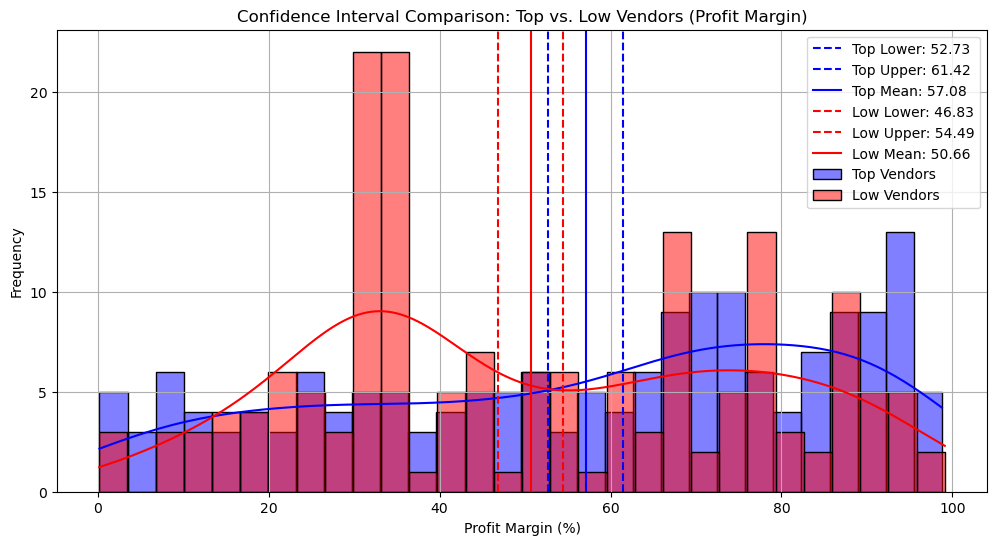

In [46]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)
 
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}") 
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")
 
plt.figure(figsize=(12, 6))
 
#Top Vendors Plot
sns.histplot(top_vendors, kde = True, color="blue", bins = 30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}") 
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue",  linestyle="-", label=f"Top Mean: {top_mean:.2f}")
 
#Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean,  color="red", linestyle="-",  label=f"Low Mean: {low_mean:.2f}")
  
#Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()
 

#### 1) The estimated profit margin for top-performing vendors (95% CI: 52.73%–61.42%) appears to be higher than that of low-performing vendors (95% CI: 46.83%–54.49%). However, since the confidence intervals overlap slightly, this alone does not conclusively establish a statistically significant difference.
 
#### 2) The results suggest that top-performing vendors may also achieve higher profit margins. However, a formal hypothesis test (such as an independent t-test) would be needed to determine whether the observed difference is statistically significant.
 
#### 3) For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
 
#### 4) For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

### Is there a significant difference in profit margins between top-performing and low-performing vendors?
  
Hypothesis:
 
H0 (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
 
H1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [47]:
top_threshold = df['TotalSalesDollers'].quantile(0.75)
low_threshold = df['TotalSalesDollers'].quantile(0.25)

top_vendors = df[df['TotalSalesDollers'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollers'] <= low_threshold]['ProfitMargin'].dropna()

# Perform Two-Sample T-test
t_stat, p_value = ttest_ind(top_vendors,low_vendors,equal_var=False)

# Print Result
print(f"T-statistic: {t_stat:.4f},P-value:{p_value:.4f}")
if p_value <0.05:
    print("Reject H0 : There is a significant difference in profit margin between top and low-performing vendors.")
else:
    print('Fail to reject H0 : NO Significant difference in Profit Margin')

T-statistic: 2.1883,P-value:0.0293
Reject H0 : There is a significant difference in profit margin between top and low-performing vendors.


In [ ]:
df.to_csv("C:/Users/akash.sukhdeve/OneDrive - iResearch Services/Attachments/PYTHON")